In [15]:
# Wine Quality Dataset (Red Wine)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directly UCI se load karein
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Dataset dekhein
print("✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset Loaded Successfully!
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
# Dataset ka overview
df.info()

# Statistical summary
df.describe()

# Check missing values
print("\n❌ Missing Values:")
print(df.isnull().sum())  # Spoiler: Koi missing nahi! ✨

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

❌ Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chl

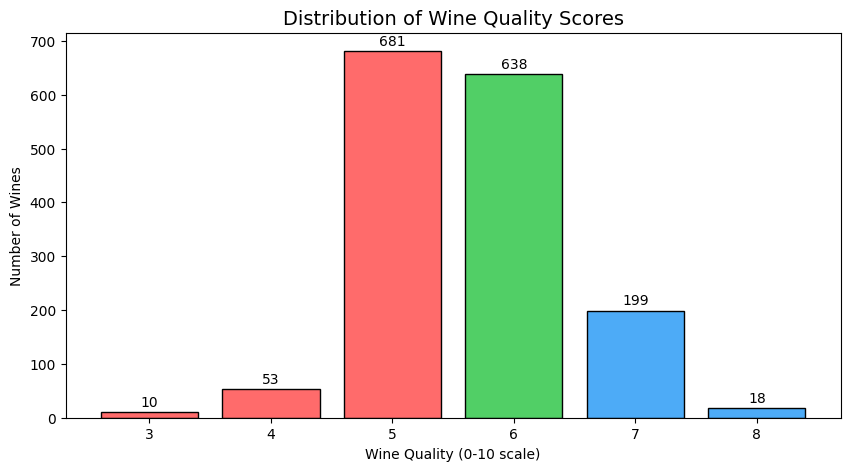

Average Quality: 5.64
Min Quality: 3
Max Quality: 8
Most common quality: 5


In [17]:
# Quality distribution
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(10,5))
colors = ['#ff6b6b' if q < 6 else '#51cf66' if q == 6 else '#4dabf7' for q in quality_counts.index]
bars = plt.bar(quality_counts.index, quality_counts.values, color=colors, edgecolor='black')
plt.xlabel('Wine Quality (0-10 scale)')
plt.ylabel('Number of Wines')
plt.title('Distribution of Wine Quality Scores', fontsize=14)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.show()

# Quality stats
print(f"Average Quality: {df['quality'].mean():.2f}")
print(f"Min Quality: {df['quality'].min()}")
print(f"Max Quality: {df['quality'].max()}")
print(f"Most common quality: {df['quality'].mode()[0]}")

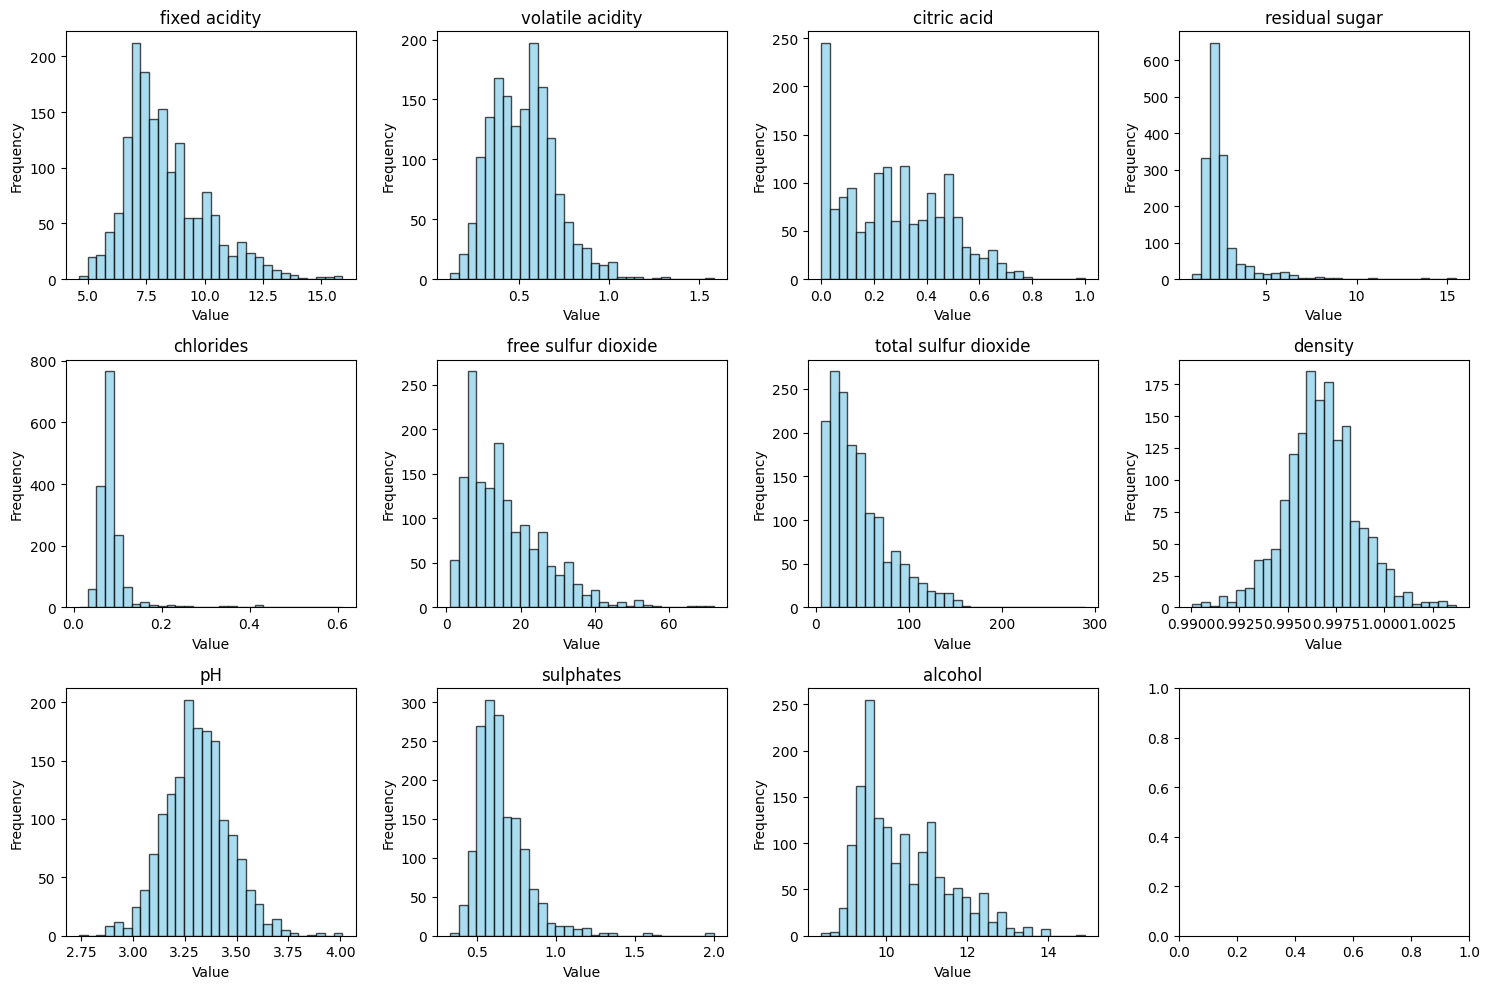

In [18]:
# All features ki distribution
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):  # Sab features except 'quality'
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\cfiza\AppData\Local\Temp\ipykernel_6416\2482797712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\cfiza\AppData\Local\Temp\ipykernel_6416\2482797712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\cfiza\AppData\Local\Temp\ipykernel_6416\2482797712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\cfiza\AppData\Local\Te

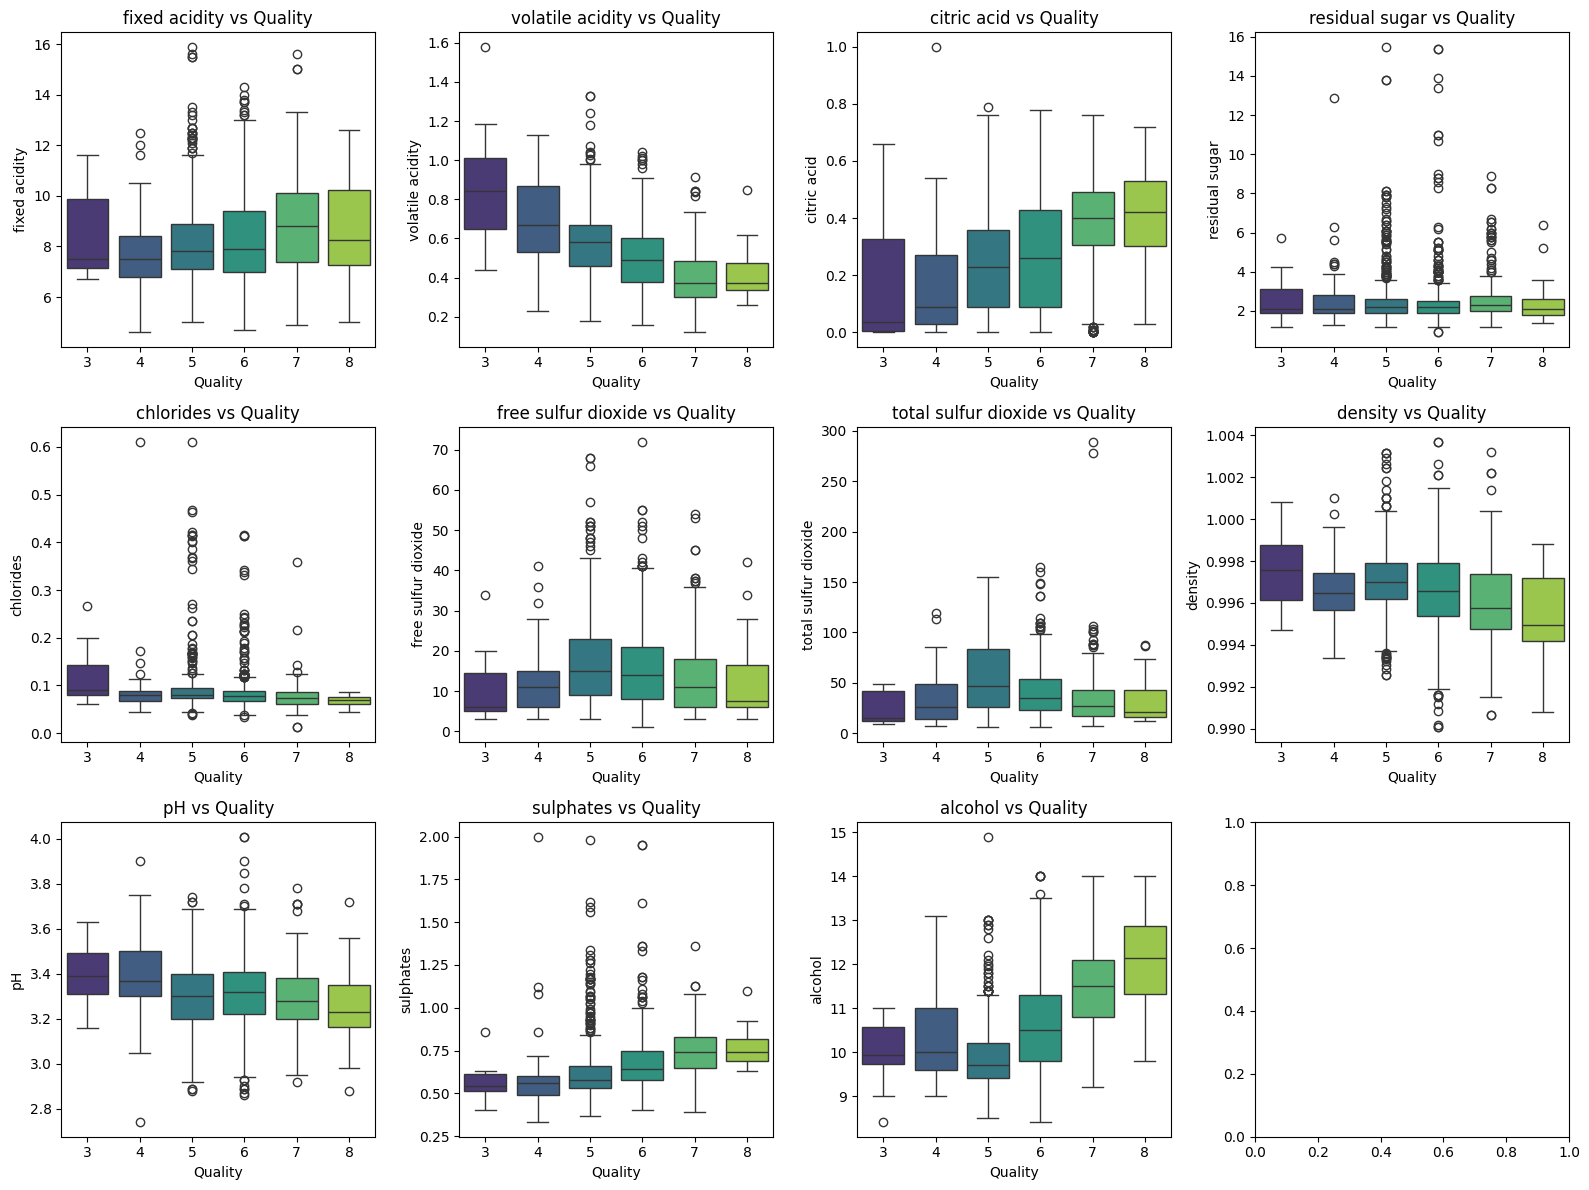

In [19]:

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    # Box plot: Feature vs Quality
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Quality')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

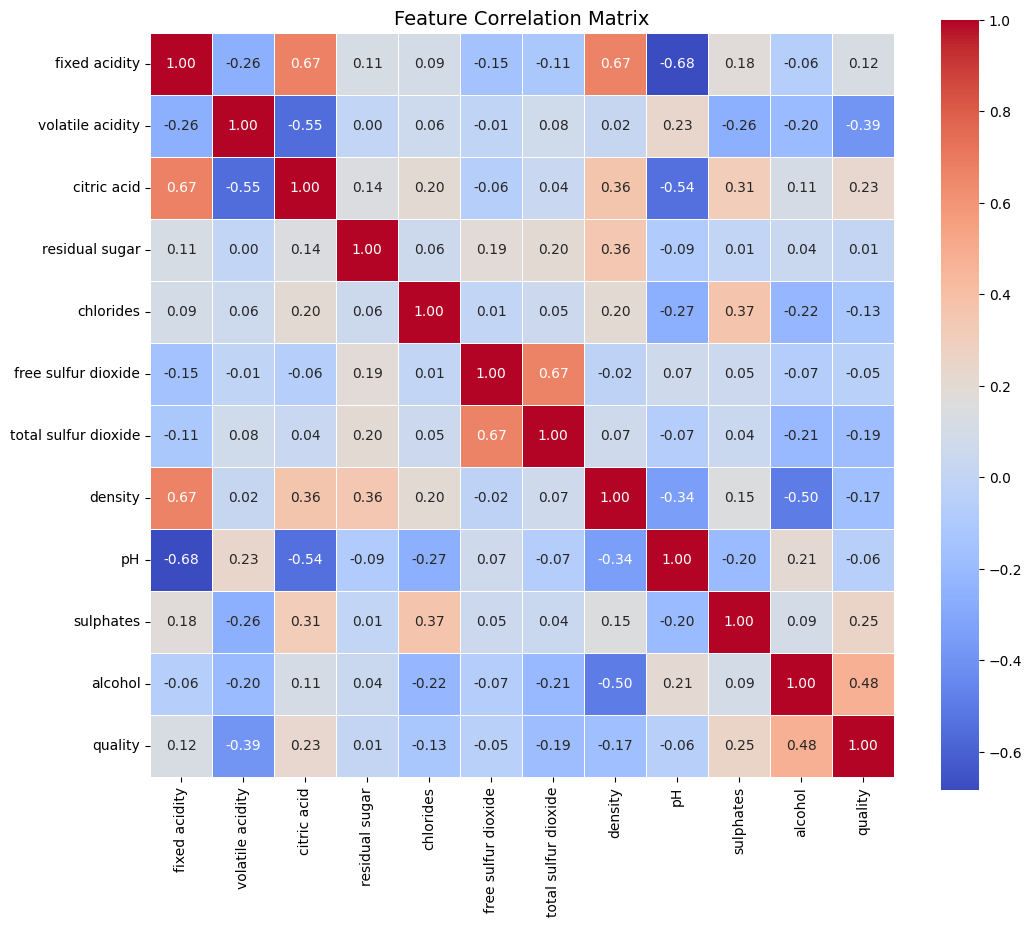


🔑 Features most correlated with Wine Quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [20]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

# Top features related to quality
quality_corr = correlation['quality'].sort_values(ascending=False)
print("\n🔑 Features most correlated with Wine Quality:")
print(quality_corr)

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Features aur Target alag karein
X = df.drop('quality', axis=1)
y = df['quality']  # Original quality scores (3-8)

# 2. [OPTION 1] Regression Task - Original quality
# y_reg = y  # Direct use karein

# 3. [OPTION 2] Classification Task - Quality ko categories mein convert karein
# Good wine (quality >= 7) vs Bad wine (quality < 7)
y_class = (y >= 7).astype(int)  # 1 = Good, 0 = Bad
print(f"Good wines: {y_class.sum()} ({y_class.mean()*100:.1f}%)")
print(f"Bad wines: {(1-y_class).sum()} ({(1-y_class.mean())*100:.1f}%)")

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, 
                                                    random_state=42, stratify=y_class)

# 5. Feature Scaling (Important for wine data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]}")
print(f"Test size: {X_test_scaled.shape[0]}")

Good wines: 217 (13.6%)
Bad wines: 1382 (86.4%)
Train size: 1279
Test size: 320


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Performance
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("🌲 Random Forest Results:")
print(f"Accuracy: {rf_acc*100:.2f}%")
print(f"AUC-ROC: {rf_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Bad', 'Good']))

🌲 Random Forest Results:
Accuracy: 93.75%
AUC-ROC: 0.930

Classification Report:
              precision    recall  f1-score   support

         Bad       0.94      0.99      0.96       277
        Good       0.93      0.58      0.71        43

    accuracy                           0.94       320
   macro avg       0.93      0.79      0.84       320
weighted avg       0.94      0.94      0.93       320



In [23]:
from xgboost import XGBClassifier

# Train XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                   scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum())
xgb.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Performance
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("🚀 XGBoost Results:")
print(f"Accuracy: {xgb_acc*100:.2f}%")
print(f"AUC-ROC: {xgb_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Bad', 'Good']))

🚀 XGBoost Results:
Accuracy: 93.12%
AUC-ROC: 0.922

Classification Report:
              precision    recall  f1-score   support

         Bad       0.96      0.96      0.96       277
        Good       0.76      0.72      0.74        43

    accuracy                           0.93       320
   macro avg       0.86      0.84      0.85       320
weighted avg       0.93      0.93      0.93       320



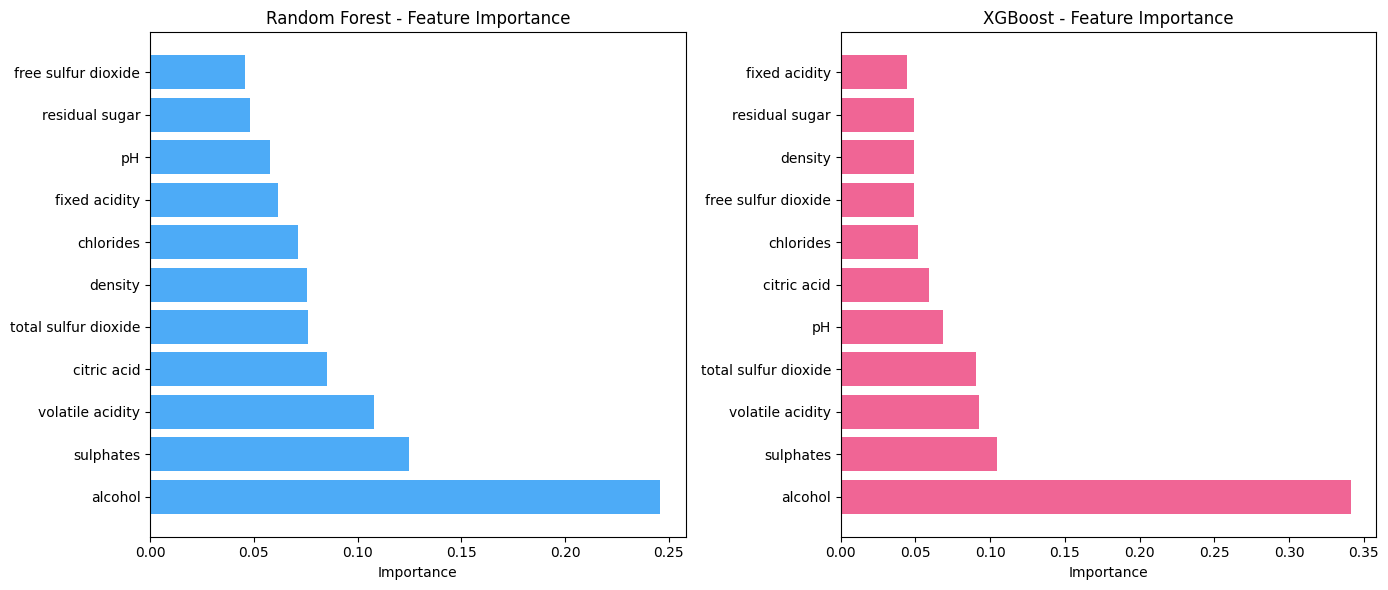


🔑 Top 5 Most Important Features (XGBoost):
                 Feature  Importance_XGB
10               alcohol        0.341436
9              sulphates        0.104807
1       volatile acidity        0.092316
6   total sulfur dioxide        0.090591
8                     pH        0.068724


In [24]:
# Compare feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance_RF': rf.feature_importances_
}).sort_values('Importance_RF', ascending=False)

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance_XGB': xgb.feature_importances_
}).sort_values('Importance_XGB', ascending=False)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
ax1.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance_RF'], 
         color='#4dabf7')
ax1.set_xlabel('Importance')
ax1.set_title('Random Forest - Feature Importance')

# XGBoost
ax2.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance_XGB'],
         color='#f06595')
ax2.set_xlabel('Importance')
ax2.set_title('XGBoost - Feature Importance')

plt.tight_layout()
plt.show()

print("\n🔑 Top 5 Most Important Features (XGBoost):")
print(feature_importance_xgb.head())

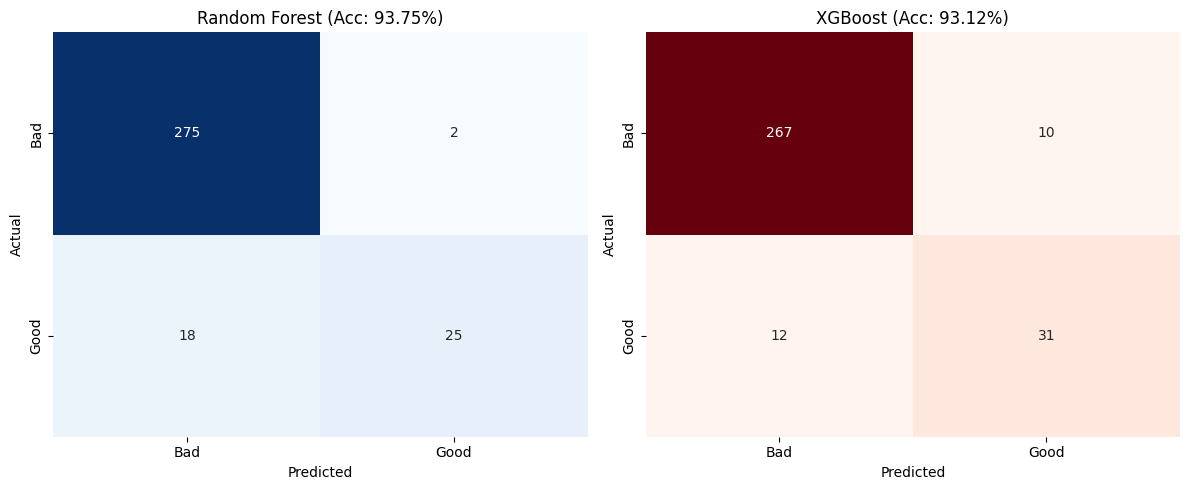

In [25]:
# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', 
            cmap='Blues', ax=ax1, cbar=False)
ax1.set_title(f'Random Forest (Acc: {rf_acc*100:.2f}%)')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticklabels(['Bad', 'Good'])
ax1.set_yticklabels(['Bad', 'Good'])

# XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d',
            cmap='Reds', ax=ax2, cbar=False)
ax2.set_title(f'XGBoost (Acc: {xgb_acc*100:.2f}%)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_xticklabels(['Bad', 'Good'])
ax2.set_yticklabels(['Bad', 'Good'])

plt.tight_layout()
plt.show()

In [26]:
# Generate insights
print("="*60)
print("🍷 WINE QUALITY ANALYSIS - KEY INSIGHTS")
print("="*60)

print("\n📊 DATA OVERVIEW:")
print(f"- Total wines analyzed: {len(df)}")
print(f"- Average quality score: {df['quality'].mean():.2f}/10")
print(f"- {y_class.sum()} wines are 'Good' (quality ≥ 7)")
print(f"- {len(df)-y_class.sum()} wines are 'Bad' (quality < 7)")

print("\n🔬 MOST IMPORTANT FEATURES FOR WINE QUALITY:")
for i, row in feature_importance_xgb.head(3).iterrows():
    print(f"  • {row['Feature'].replace('_', ' ').title()}: {row['Importance_XGB']:.3f}")

print("\n🤖 MODEL PERFORMANCE:")
print(f"  • Random Forest: {rf_acc*100:.1f}% accuracy")
print(f"  • XGBoost: {xgb_acc*100:.1f}% accuracy")
print(f"  • Best Model: {'XGBoost' if xgb_acc > rf_acc else 'Random Forest'}")

print("\n💼 BUSINESS RECOMMENDATIONS:")
print("1. Focus on 'alcohol' level - highest impact on quality")
print("2. Monitor 'sulphates' and 'volatile acidity' closely")
print("3. Target wine quality ≥ 7 for premium pricing")
print("4. Use this model to predict quality before bottling")

🍷 WINE QUALITY ANALYSIS - KEY INSIGHTS

📊 DATA OVERVIEW:
- Total wines analyzed: 1599
- Average quality score: 5.64/10
- 217 wines are 'Good' (quality ≥ 7)
- 1382 wines are 'Bad' (quality < 7)

🔬 MOST IMPORTANT FEATURES FOR WINE QUALITY:
  • Alcohol: 0.341
  • Sulphates: 0.105
  • Volatile Acidity: 0.092

🤖 MODEL PERFORMANCE:
  • Random Forest: 93.8% accuracy
  • XGBoost: 93.1% accuracy
  • Best Model: Random Forest

💼 BUSINESS RECOMMENDATIONS:
1. Focus on 'alcohol' level - highest impact on quality
2. Monitor 'sulphates' and 'volatile acidity' closely
3. Target wine quality ≥ 7 for premium pricing
4. Use this model to predict quality before bottling
